# agentv17_mcp_integration — LangGraph + MCP

This version introduces a local MCP server and a LangGraph agent that calls MCP tools.

Graph:

```text
START → planner → mcp_tools → summarize → END
```

MCP is important because production tools often live outside the agent process.


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter mcp
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter mcp


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Create local MCP server file

This notebook writes `mcp_server.py`.

The server exposes two MCP tools:

- `get_epp_metrics`
- `get_epp_runbook`


In [4]:
from pathlib import Path

MCP_SERVER_PATH = Path("mcp_server.py")

MCP_SERVER_PATH.write_text("""
from __future__ import annotations

from mcp.server.fastmcp import FastMCP

mcp = FastMCP("epp-mcp-server")


@mcp.tool()
def get_epp_metrics(issue: str) -> str:
    \"""Return simulated EPP metrics for an incident investigation.\"""
    return (
        "EPP Metrics: CHECK-DOMAIN p95 response_time is 240 ms after R13. "
        "CONNECTION_TIMEOUT failure volume increased for client_b during peak hours. "
        f"Investigation issue: {issue}"
    )


@mcp.tool()
def get_epp_runbook(issue: str) -> str:
    \"""Return simulated runbook guidance for an EPP incident.\"""
    return (
        "Runbook Guidance: For CHECK-DOMAIN timeout spikes, inspect upstream registry "
        "connectivity, DNS resolver latency, registry endpoint health, and connection "
        "pool saturation. Rollback if timeout volume remains above baseline for two "
        "consecutive hours. "
        f"Investigation issue: {issue}"
    )


if __name__ == "__main__":
    mcp.run()
""")

print("Created:", MCP_SERVER_PATH.resolve())


Created: /home/aimlnode/Workplace/Projects/langgraph-playground/langgraph-playground-v1-notebook/agentv17_mcp_integration/mcp_server.py


## 4. Define state using NotRequired


In [5]:
from typing import NotRequired, TypedDict

class AgentState(TypedDict):
    input: str
    plan: NotRequired[str]
    metrics_context: NotRequired[str]
    runbook_context: NotRequired[str]
    final_answer: NotRequired[str]


## 5. Define MCP client helper


In [6]:
import sys
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

async def call_mcp_tool(tool_name: str, arguments: dict) -> str:
    server_params = StdioServerParameters(
        command=sys.executable,
        args=[str(MCP_SERVER_PATH.resolve())],
    )

    async with stdio_client(server_params) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()
            result = await session.call_tool(tool_name, arguments=arguments)

    return "\n".join(
        item.text for item in result.content if getattr(item, "type", None) == "text"
    )


## 6. Test MCP tools directly


In [7]:
metrics = await call_mcp_tool(
    "get_epp_metrics",
    {"issue": "CHECK-DOMAIN timeout after R13"},
)

runbook = await call_mcp_tool(
    "get_epp_runbook",
    {"issue": "CHECK-DOMAIN timeout after R13"},
)

print(metrics)
print()
print(runbook)


EPP Metrics: CHECK-DOMAIN p95 response_time is 240 ms after R13. CONNECTION_TIMEOUT failure volume increased for client_b during peak hours. Investigation issue: CHECK-DOMAIN timeout after R13

Runbook Guidance: For CHECK-DOMAIN timeout spikes, inspect upstream registry connectivity, DNS resolver latency, registry endpoint health, and connection pool saturation. Rollback if timeout volume remains above baseline for two consecutive hours. Investigation issue: CHECK-DOMAIN timeout after R13


## 7. Define LangGraph async nodes


In [8]:
import asyncio
from langchain_openai import ChatOpenAI

async def planner_node(state: AgentState) -> AgentState:
    return {
        "plan": (
            "Plan: call MCP metrics tool and MCP runbook tool, then synthesize "
            "the incident analysis."
        )
    }

async def mcp_tools_node(state: AgentState) -> AgentState:
    metrics_task = call_mcp_tool("get_epp_metrics", {"issue": state["input"]})
    runbook_task = call_mcp_tool("get_epp_runbook", {"issue": state["input"]})

    metrics_context, runbook_context = await asyncio.gather(
        metrics_task,
        runbook_task,
    )

    return {
        "metrics_context": metrics_context,
        "runbook_context": runbook_context,
    }

async def summarize_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    prompt = f'''
User request:
{state["input"]}

Plan:
{state["plan"]}

MCP metrics context:
{state["metrics_context"]}

MCP runbook context:
{state["runbook_context"]}

Write a concise incident analysis with:
1. likely cause
2. supporting evidence
3. recommended next action
'''

    response = await llm.ainvoke(prompt)
    return {"final_answer": response.content}


## 8. Build graph


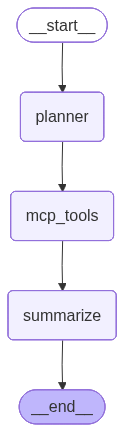

In [9]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    g = StateGraph(AgentState)

    g.add_node("planner", planner_node)
    g.add_node("mcp_tools", mcp_tools_node)
    g.add_node("summarize", summarize_node)

    g.add_edge(START, "planner")
    g.add_edge("planner", "mcp_tools")
    g.add_edge("mcp_tools", "summarize")
    g.add_edge("summarize", END)

    return g.compile()

graph = build_graph()
graph


## 9. Visualize graph


In [10]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	mcp_tools(mcp_tools)
	summarize(summarize)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	mcp_tools --> summarize;
	planner --> mcp_tools;
	summarize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 10. Visualize PNG


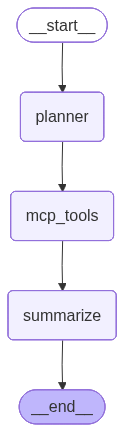

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed:", e)


## 11. Run MCP-integrated graph


In [12]:
result = await graph.ainvoke({
    "input": "Investigate CHECK-DOMAIN timeout issue after release R13."
})

print(result["final_answer"])


### Incident Analysis: CHECK-DOMAIN Timeout Issue After Release R13

#### 1. Likely Cause
The increase in CONNECTION_TIMEOUT failures for CHECK-DOMAIN after release R13 is likely due to degraded upstream registry connectivity and potential DNS resolver latency. The observed p95 response time of 240 ms indicates that the service is experiencing delays, which may be exacerbated during peak hours when client_b is active.

#### 2. Supporting Evidence
- **EPP Metrics**: The p95 response time for CHECK-DOMAIN has risen to 240 ms post-R13, indicating a significant performance degradation.
- **Failure Volume**: There has been a noticeable increase in CONNECTION_TIMEOUT failures specifically for client_b during peak hours, suggesting that the issue is not uniformly distributed but rather concentrated under high load conditions.
- **Runbook Guidance**: The runbook advises checking upstream registry connectivity and DNS resolver latency, both of which are critical factors that could contribute to

## 12. Inspect MCP contexts


In [13]:
print("METRICS CONTEXT:")
print(result["metrics_context"])
print()
print("RUNBOOK CONTEXT:")
print(result["runbook_context"])


METRICS CONTEXT:
EPP Metrics: CHECK-DOMAIN p95 response_time is 240 ms after R13. CONNECTION_TIMEOUT failure volume increased for client_b during peak hours. Investigation issue: Investigate CHECK-DOMAIN timeout issue after release R13.

RUNBOOK CONTEXT:
Runbook Guidance: For CHECK-DOMAIN timeout spikes, inspect upstream registry connectivity, DNS resolver latency, registry endpoint health, and connection pool saturation. Rollback if timeout volume remains above baseline for two consecutive hours. Investigation issue: Investigate CHECK-DOMAIN timeout issue after release R13.


## 13. Stream async graph updates


In [14]:
async for chunk in graph.astream(
    {"input": "Investigate CHECK-DOMAIN timeout issue after release R13."},
    stream_mode="updates",
):
    print("\n--- update ---")
    print(chunk)



--- update ---
{'planner': {'plan': 'Plan: call MCP metrics tool and MCP runbook tool, then synthesize the incident analysis.'}}

--- update ---
{'mcp_tools': {'metrics_context': 'EPP Metrics: CHECK-DOMAIN p95 response_time is 240 ms after R13. CONNECTION_TIMEOUT failure volume increased for client_b during peak hours. Investigation issue: Investigate CHECK-DOMAIN timeout issue after release R13.', 'runbook_context': 'Runbook Guidance: For CHECK-DOMAIN timeout spikes, inspect upstream registry connectivity, DNS resolver latency, registry endpoint health, and connection pool saturation. Rollback if timeout volume remains above baseline for two consecutive hours. Investigation issue: Investigate CHECK-DOMAIN timeout issue after release R13.'}}

--- update ---
{'summarize': {'final_answer': '### Incident Analysis: CHECK-DOMAIN Timeout Issue After Release R13\n\n#### 1. Likely Cause\nThe increase in CONNECTION_TIMEOUT failures for CHECK-DOMAIN after release R13 is likely due to degraded u

## 14. Why this matters

MCP creates a production-style boundary:

```text
Agent orchestration code
  ↔ MCP server
      ↔ enterprise tools
```

This lets multiple agents reuse the same tool server.


## 15. LangSmith trace

Open project:

```text
langgraph-playground
```

Inspect the graph run, MCP tool node, and final LLM synthesis.
